In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style('darkgrid')
sns.set_palette('viridis')

print("All libraries imported successfully!")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Seaborn version:", sns.__version__)

All libraries imported successfully!
NumPy version: 2.4.6
Pandas version: 3.0.3
Seaborn version: 0.13.2


In [2]:
# Load iris dataset — built into seaborn just like tips!
df = sns.load_dataset('iris')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (150, 5)


Cell 3 — Box Plot

In [6]:
# Before we code — quick reminder of how to read a box plot from what you learned earlier:

# Top whisker    → Maximum value
# Top of box     → 75% of data below this
# Middle line    → Median
# Bottom of box  → 25% of data below this
# Bottom whisker → Minimum value

/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_23508/2813677711.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([setosa_petals, versicolor_petals, virginica_petals],


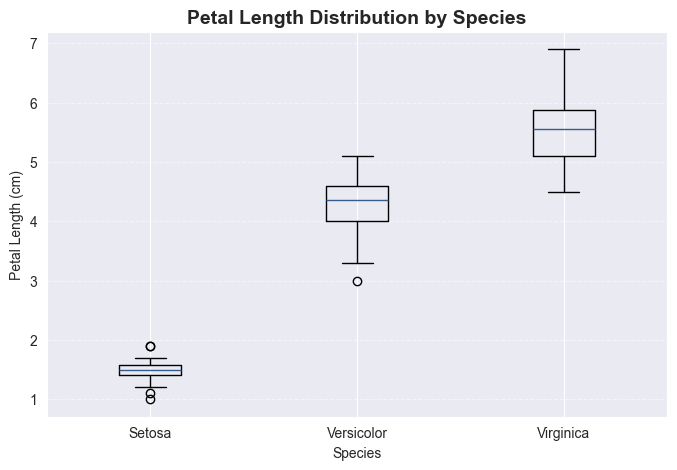

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

# Group data by species for box plot
setosa_petals = df[df['species']=='setosa']['petal_length']
versicolor_petals = df[df['species']=='versicolor']['petal_length']
virginica_petals = df[df['species']=='virginica']['petal_length']

ax.boxplot([setosa_petals, versicolor_petals, virginica_petals],
           labels=['Setosa', 'Versicolor', 'Virginica'])

ax.set_title('Petal Length Distribution by Species', fontsize=14, fontweight='bold')
ax.set_xlabel('Species')
ax.set_ylabel('Petal Length (cm)')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Why box plot is better than histogram for outliers:

Histogram → shows you distribution but outliers hide in the bars

Box plot  → explicitly marks outliers as separate circles

In [4]:
# Find Setosa outliers in petal_length
Q1 = df[df['species']=='setosa']['petal_length'].quantile(0.25)
Q3 = df[df['species']=='setosa']['petal_length'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower boundary:", Q1 - 1.5 * IQR)
print("Upper boundary:", Q3 + 1.5 * IQR)

# Any values outside boundaries are outliers
outliers = df[df['species']=='setosa'][
    (df[df['species']=='setosa']['petal_length'] < Q1 - 1.5*IQR) |
    (df[df['species']=='setosa']['petal_length'] > Q3 + 1.5*IQR)
]
print("\nSetosa outliers:")
print(outliers)

Q1: 1.4
Q3: 1.5750000000000002
IQR: 0.17500000000000027
Lower boundary: 1.1374999999999995
Upper boundary: 1.8375000000000006

Setosa outliers:
    sepal_length  sepal_width  petal_length  petal_width species
13           4.3          3.0           1.1          0.1  setosa
22           4.6          3.6           1.0          0.2  setosa
24           4.8          3.4           1.9          0.2  setosa
44           5.1          3.8           1.9          0.4  setosa
